In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
import optuna

In [4]:
df = pd.read_csv("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/data/processed/Dinner_feature_2024_2025.csv", parse_dates=["Date"])
holdout_df = pd.read_csv("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/data/processed/Dinner_feature_2026.csv", parse_dates=["Date"])

In [5]:
df.shape

(731, 46)

In [6]:
df.head()

,Date,DayOfWeek,DayOfMonth,Month,Is_Start_Of_Month,Is_End_Of_Month,Is_Weekend,Is_Holiday,Is_Vacation,Is_Exam_Period,...,Target_14_Day_Std,Target_14_Day_Max,Target_14_Day_Min,Target_28_Day_Avg,Target_28_Day_Std,Target_28_Day_Max,Target_28_Day_Min,Target_EWMA_7,Target_EWMA_14,Trend_7_vs_28
0,2024-01-01,Monday,1,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,Tuesday,2,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0000,20.000000,NaN
2,2024-01-03,Wednesday,3,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0000,21.600000,NaN
3,2024-01-04,Thursday,4,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.7500,30.186667,NaN
4,2024-01-05,Friday,5,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.0625,34.161778,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                731 non-null    datetime64[us]
 1   DayOfWeek           731 non-null    str           
 2   DayOfMonth          731 non-null    int64         
 3   Month               731 non-null    int64         
 4   Is_Start_Of_Month   731 non-null    int64         
 5   Is_End_Of_Month     731 non-null    int64         
 6   Is_Weekend          731 non-null    int64         
 7   Is_Holiday          731 non-null    int64         
 8   Is_Vacation         731 non-null    int64         
 9   Is_Exam_Period      731 non-null    int64         
 10  Is_Fest             731 non-null    int64         
 11  Days_Until_Holiday  731 non-null    float64       
 12  DayOfWeek_Sin       731 non-null    float64       
 13  DayOfWeek_Cos       731 non-null    float64       
 14  Month

In [9]:
df_clean = df.dropna().reset_index(drop=True)
print(len(df), ",", len(df_clean))

731 , 601


In [10]:
feature_cols = [c for c in df_clean.columns if c not in ["Date", "Target_Headcount", "Category", "Notes", "DayOfWeek"]]

X = df_clean[feature_cols]
Y = df_clean["Target_Headcount"]

In [11]:
train_mask = df_clean["Date"].dt.year == 2024
validate_mask = df_clean["Date"].dt.year == 2025

X_train, Y_train = X[train_mask], Y[train_mask]
X_validate, Y_validate = X[validate_mask], Y[validate_mask]

print(len(X_train), len(Y_train), "\n", len(X_validate), len(Y_validate))

256 256 
 345 345


In [12]:
print(X_train.shape)
print(X_validate.shape)

print(df_clean.loc[train_mask, "Date"].min(), df_clean.loc[train_mask, "Date"].max())
print(df_clean.loc[validate_mask, "Date"].min(), df_clean.loc[validate_mask, "Date"].max())

(256, 43)
(345, 43)
2024-01-29 00:00:00 2024-12-07 00:00:00
2025-01-21 00:00:00 2025-12-31 00:00:00


In [13]:
print(X_train.iloc[100])

DayOfMonth              8.000000
Month                   5.000000
Is_Start_Of_Month       0.000000
Is_End_Of_Month         0.000000
Is_Weekend              0.000000
Is_Holiday              0.000000
Is_Vacation             0.000000
Is_Exam_Period          1.000000
Is_Fest                 0.000000
Days_Until_Holiday     99.000000
DayOfWeek_Sin           0.974928
DayOfWeek_Cos          -0.222521
Month_Sin               0.500000
Month_Cos              -0.866025
Is_Broke_Weekend        0.000000
Is_Rich_Weekend         0.000000
WeekOfYear             19.000000
DayOfYear             129.000000
Target_1_Days_Ago     125.000000
Target_2_Days_Ago     160.000000
Target_3_Days_Ago     210.000000
Target_7_Days_Ago     178.000000
Target_14_Days_Ago    340.000000
Target_21_Days_Ago    310.000000
Target_3_Day_Avg      165.000000
Target_3_Day_Std       42.720019
Target_3_Day_Max      210.000000
Target_3_Day_Min      125.000000
Target_7_Day_Avg      156.714286
Target_7_Day_Std       37.039233
Target_7_D

In [14]:
check_date = df_clean[df_clean["Date"] == "2024-08-10"]
print(check_date[["Date", "Target_Headcount", "Target_7_Days_Ago"]])

seven_days_before = df_clean[df_clean["Date"] == "2024-08-03"]
print(seven_days_before[["Date", "Target_Headcount"]])

          Date  Target_Headcount  Target_7_Days_Ago
136 2024-08-10              94.0              128.0
          Date  Target_Headcount
129 2024-08-03             128.0


In [15]:
window = df_clean[df_clean["Date"].between("2024-03-09", "2024-03-15")]
print(window[["Date", "Target_Headcount"]])
print("Manual 7-day avg:", window["Target_Headcount"].mean())

print("Target_7_Day_Avg column says:", df_clean[df_clean["Date"] == "2024-03-16"]["Target_7_Day_Avg"].values)

         Date  Target_Headcount
40 2024-03-09              84.0
41 2024-03-10             212.0
42 2024-03-11             258.0
43 2024-03-12             254.0
44 2024-03-13             373.0
45 2024-03-14             290.0
46 2024-03-15             152.0
Manual 7-day avg: 231.85714285714286
Target_7_Day_Avg column says: [231.85714286]


In [16]:
"Target_Headcount" in feature_cols

False

In [17]:
X_train.isna().sum().sum()
X_validate.isna().sum().sum()

np.int64(0)

In [18]:
print(len(feature_cols))
print(feature_cols)

43
['DayOfMonth', 'Month', 'Is_Start_Of_Month', 'Is_End_Of_Month', 'Is_Weekend', 'Is_Holiday', 'Is_Vacation', 'Is_Exam_Period', 'Is_Fest', 'Days_Until_Holiday', 'DayOfWeek_Sin', 'DayOfWeek_Cos', 'Month_Sin', 'Month_Cos', 'Is_Broke_Weekend', 'Is_Rich_Weekend', 'WeekOfYear', 'DayOfYear', 'Target_1_Days_Ago', 'Target_2_Days_Ago', 'Target_3_Days_Ago', 'Target_7_Days_Ago', 'Target_14_Days_Ago', 'Target_21_Days_Ago', 'Target_3_Day_Avg', 'Target_3_Day_Std', 'Target_3_Day_Max', 'Target_3_Day_Min', 'Target_7_Day_Avg', 'Target_7_Day_Std', 'Target_7_Day_Max', 'Target_7_Day_Min', 'Target_14_Day_Avg', 'Target_14_Day_Std', 'Target_14_Day_Max', 'Target_14_Day_Min', 'Target_28_Day_Avg', 'Target_28_Day_Std', 'Target_28_Day_Max', 'Target_28_Day_Min', 'Target_EWMA_7', 'Target_EWMA_14', 'Trend_7_vs_28']


In [19]:
model = CatBoostRegressor(random_state=28)

In [20]:
model.fit(X_train, Y_train)

Learning rate set to 0.033013
0:	learn: 141.3697759	total: 51.7ms	remaining: 51.6s
1:	learn: 139.1832950	total: 54.2ms	remaining: 27.1s
2:	learn: 136.6483909	total: 56.4ms	remaining: 18.7s
3:	learn: 134.5449672	total: 57.8ms	remaining: 14.4s
4:	learn: 132.4867857	total: 59.2ms	remaining: 11.8s
5:	learn: 130.3776055	total: 60.3ms	remaining: 9.99s
6:	learn: 128.4909614	total: 61.4ms	remaining: 8.71s
7:	learn: 126.7879856	total: 63.4ms	remaining: 7.86s
8:	learn: 124.5753127	total: 64.7ms	remaining: 7.13s
9:	learn: 122.5519929	total: 66.2ms	remaining: 6.55s
10:	learn: 120.8954407	total: 68.1ms	remaining: 6.12s
11:	learn: 119.0753292	total: 70ms	remaining: 5.76s
12:	learn: 117.2709340	total: 71.5ms	remaining: 5.43s
13:	learn: 115.4466080	total: 73.5ms	remaining: 5.18s
14:	learn: 113.8290640	total: 75.1ms	remaining: 4.93s
15:	learn: 112.1019486	total: 76.7ms	remaining: 4.71s
16:	learn: 110.6381052	total: 78.1ms	remaining: 4.51s
17:	learn: 109.0939669	total: 79.5ms	remaining: 4.34s
18:	learn:

CatBoostRegressor(loss_function='RMSE', random_state=28)

In [21]:
prediction = model.predict(X_validate)

In [22]:
mae = mean_absolute_error(Y_validate, prediction)
rmse = np.sqrt(mean_squared_error(Y_validate, prediction))

baseline_pred = X_validate["Target_7_Days_Ago"]
actual = Y_validate
mask = baseline_pred.notna() & actual.notna()
baseline_mae = (actual[mask] - baseline_pred[mask]).abs().mean()
baseline_rmse = np.sqrt(mean_squared_error(actual[mask], baseline_pred[mask]))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Model MAE:", mae)
print("Model RMSE:", rmse)

Baseline MAE: 74.93913043478261
Baseline RMSE: 108.65779949596048
Model MAE: 59.07251670263641
Model RMSE: 73.269699501936


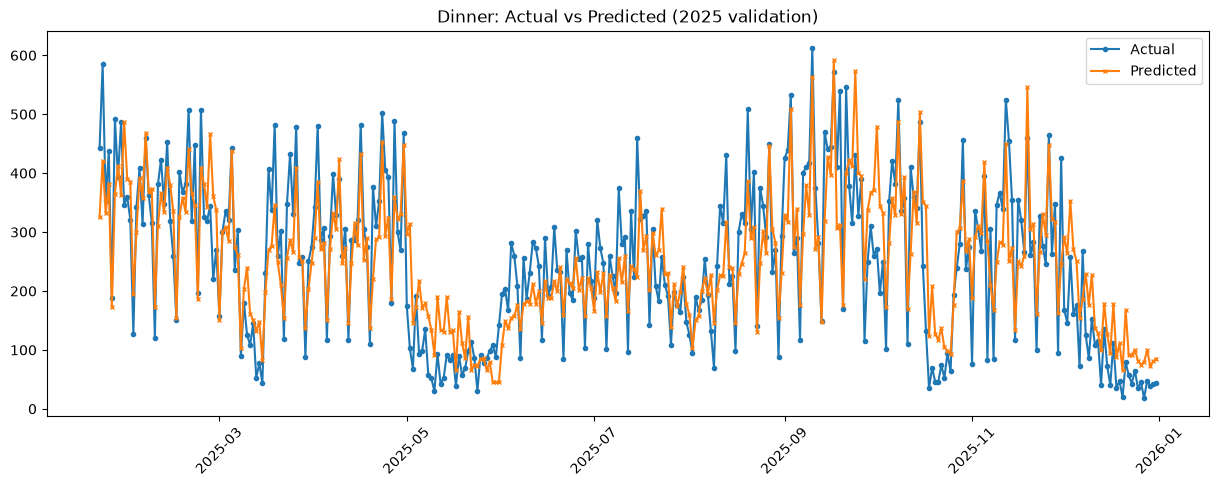

In [23]:
val_dates = df_clean.loc[validate_mask, "Date"]

plt.figure(figsize=(15,5))
plt.plot(val_dates, Y_validate.values, label="Actual", marker='o', markersize=3)
plt.plot(val_dates, prediction, label="Predicted", marker='x', markersize=3)
plt.legend()
plt.title("Dinner: Actual vs Predicted (2025 validation)")
plt.xticks(rotation=45)
plt.show()

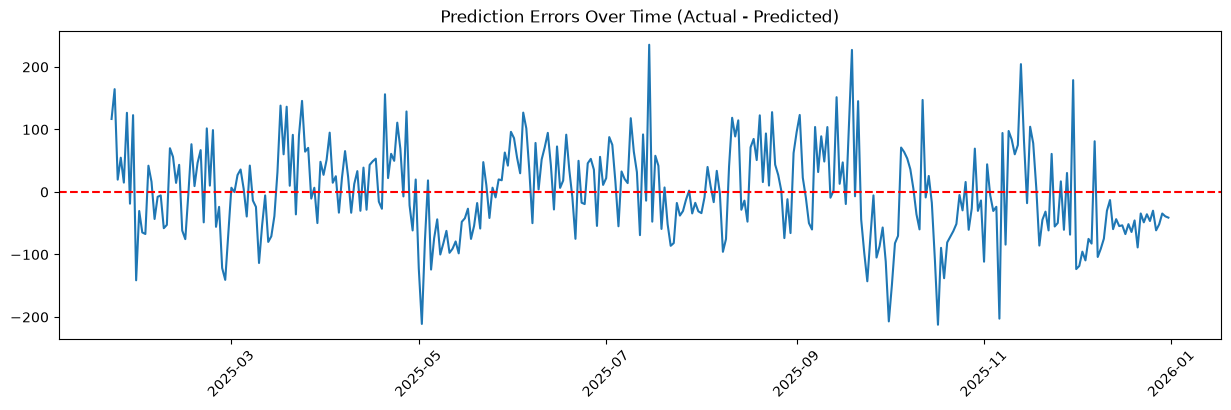

In [24]:
residuals = Y_validate.values - prediction

plt.figure(figsize=(15,4))
plt.plot(val_dates, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Prediction Errors Over Time (Actual - Predicted)")
plt.xticks(rotation=45)
plt.show()

In [25]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15)

DayOfWeek_Sin         10.942406
Target_7_Days_Ago      9.785602
Target_21_Days_Ago     8.501361
Target_14_Days_Ago     8.167569
Target_1_Days_Ago      7.450737
Target_3_Day_Max       5.185893
Days_Until_Holiday     3.604474
Target_3_Day_Avg       3.146087
DayOfWeek_Cos          3.074688
Target_2_Days_Ago      3.007245
Target_3_Day_Min       2.904357
Target_3_Days_Ago      2.385856
Target_14_Day_Avg      2.008869
Target_3_Day_Std       1.961407
DayOfYear              1.860398
dtype: float64

In [26]:
df_sorted = df_clean.sort_values("Date").reset_index(drop=True)

fold_windows = [
    ("2024-01-01", "2024-12-31", "2025-01-01", "2025-03-01"),
    ("2024-01-01", "2025-03-01", "2025-03-01", "2025-05-01"),
    ("2024-01-01", "2025-05-01", "2025-05-01", "2025-07-01"),
    ("2024-01-01", "2025-07-01", "2025-07-01", "2025-09-01"),
    ("2024-01-01", "2025-09-01", "2025-09-01", "2025-11-01"),
    ("2024-01-01", "2025-11-01", "2025-11-01", "2025-12-31"),
]
results = []

for name, ModelClass, params in [
    ("RandomForest", RandomForestRegressor, {"random_state":28}),
    ("XGBoost", XGBRegressor, {"random_state": 28}),
    ("LightGBM", LGBMRegressor, {"random_state": 28, "verbose": -1}),
    ("CatBoost", CatBoostRegressor, {"random_state": 28, "verbose": 0}),
]:
    fold_MAEs = []
    fold_RMSEs = []
    
    for train_start, train_end, val_start, val_end in fold_windows:
        
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        
        model = ModelClass(**params)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_MAEs.append(mean_absolute_error(val_fold["Target_Headcount"], pred))
        fold_RMSEs.append(np.sqrt(mean_squared_error(val_fold["Target_Headcount"], pred)))
        
    results.append({
        "Model": name,
        "MAE": np.mean(fold_MAEs),
        "MAE STD": np.std(fold_MAEs),
        "RMSE": np.mean(fold_RMSEs),
        "RMSE STD": np.std(fold_RMSEs),
    })

    print(f"{name}")
    print(f"Average MAE  : {np.mean(fold_MAEs):.2f} ± {np.std(fold_MAEs):.2f}")
    print(f"Average RMSE : {np.mean(fold_RMSEs):.2f} ± {np.std(fold_RMSEs):.2f}")
    print(f"Fold MAEs    : {[round(float(x),1) for x in fold_MAEs]}")
    print(f"Fold RMSEs   : {[round(float(x),1) for x in fold_RMSEs]}")
    print()

RandomForest
Average MAE  : 56.21 ± 9.02
Average RMSE : 71.92 ± 9.11
Fold MAEs    : [64.0, 51.3, 47.2, 45.9, 70.8, 58.1]
Fold RMSEs   : [79.0, 64.6, 62.9, 62.0, 85.6, 77.4]

XGBoost
Average MAE  : 59.12 ± 13.68
Average RMSE : 73.42 ± 13.84
Fold MAEs    : [55.3, 48.7, 49.2, 46.6, 71.6, 83.4]
Fold RMSEs   : [64.6, 59.8, 67.3, 64.4, 86.4, 97.9]

LightGBM
Average MAE  : 55.43 ± 9.50
Average RMSE : 72.32 ± 9.86
Fold MAEs    : [62.1, 50.3, 49.4, 43.6, 72.5, 54.6]
Fold RMSEs   : [77.5, 64.6, 65.1, 60.5, 89.2, 76.8]

CatBoost
Average MAE  : 54.57 ± 6.52
Average RMSE : 69.14 ± 6.92
Fold MAEs    : [60.5, 46.4, 55.0, 45.3, 58.3, 61.9]
Fold RMSEs   : [73.9, 58.7, 70.3, 60.7, 75.0, 76.1]



In [25]:
def objective(trial):
    parameters = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 12),  # widened from 8

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        
        "random_state": 28,
        "n_jobs": -1,
    }

    fold_maes = []
    for train_start, train_end, val_start, val_end in fold_windows:
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        model = XGBRegressor(**parameters)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_maes.append(mean_absolute_error(val_fold["Target_Headcount"], pred))

    return np.mean(fold_maes)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=28, multivariate=True, group=True)
)
study.optimize(objective, n_trials=400, show_progress_bar=True)  # bumped from 100

print("\nBest MAE:")
print(f"{study.best_value:.2f}")
print("\nBest Parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")
print("\nTop 10 Trials:")
display(study.trials_dataframe().sort_values("value").head(10))

/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-10 10:35:15,726] A new study created in memory with name: no-name-b1d1ab51-6fe9-4cf6-a748-79f3dd2f0c22


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-07-10 10:35:17,482] Trial 0 finished with value: 55.46588947324445 and parameters: {'learning_rate': 0.09891603549518685, 'n_estimators': 493, 'max_depth': 4, 'min_child_weight': 6, 'gamma': 3.9065410313673805, 'reg_alpha': 0.11065522526191614, 'reg_lambda': 0.005379890467195983, 'subsample': 0.9267564376244264, 'colsample_bytree': 0.9776859463174046}. Best is trial 0 with value: 55.46588947324445.
[I 2026-07-10 10:35:19,296] Trial 1 finished with value: 57.21309987595314 and parameters: {'learning_rate': 0.2812227258994409, 'n_estimators': 235, 'max_depth': 12, 'min_child_weight': 4, 'gamma': 0.1317692425493533, 'reg_alpha': 6.0847308477212225, 'reg_lambda': 4.862945563972716, 'subsample': 0.6469878839059903, 'colsample_bytree': 0.5831368510995121}. Best is trial 0 with value: 55.46588947324445.
[I 2026-07-10 10:35:21,648] Trial 2 finished with value: 54.55682726510525 and parameters: {'learning_rate': 0.02524013197544389, 'n_estimators': 457, 'max_depth': 6, 'min_child_weight

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
90,90,51.976823,2026-07-10 10:41:17.883588,2026-07-10 10:41:21.882652,0 days 00:00:03.999064,0.611449,0.300165,0.014121,5,13,730,0.033617,9.440222,0.900671,COMPLETE
271,271,52.138423,2026-07-10 10:50:27.442172,2026-07-10 10:50:29.466806,0 days 00:00:02.024634,0.856521,2.516723,0.022352,5,15,396,0.136287,0.114247,0.667190,COMPLETE
381,381,52.166517,2026-07-10 10:56:26.397446,2026-07-10 10:56:28.580507,0 days 00:00:02.183061,0.907653,0.648636,0.026644,6,13,353,3.603166,0.036119,0.556831,COMPLETE
367,367,52.201821,2026-07-10 10:55:27.545262,2026-07-10 10:55:30.254194,0 days 00:00:02.708932,0.864579,2.791118,0.012424,10,15,386,0.003760,0.003180,0.773437,COMPLETE
118,118,52.235133,2026-07-10 10:43:07.721776,2026-07-10 10:43:09.967516,0 days 00:00:02.245740,0.967356,0.943382,0.019527,8,13,392,7.891588,0.010756,0.571294,COMPLETE
218,218,52.242749,2026-07-10 10:47:43.696454,2026-07-10 10:47:45.368664,0 days 00:00:01.672210,0.976859,0.506930,0.019168,6,15,314,4.063668,0.030915,0.681101,COMPLETE
250,250,52.318778,2026-07-10 10:49:17.333028,2026-07-10 10:49:21.005323,0 days 00:00:03.672295,0.557332,1.098912,0.011198,6,14,768,0.029846,6.285383,0.872696,COMPLETE
102,102,52.366234,2026-07-10 10:42:04.866179,2026-07-10 10:42:08.162813,0 days 00:00:03.296634,0.900512,0.210121,0.020005,9,14,557,1.944709,0.015855,0.655650,COMPLETE
370,370,52.370665,2026-07-10 10:55:39.513776,2026-07-10 10:55:45.737199,0 days 00:00:06.223423,0.822367,3.127061,0.012408,10,15,513,0.002386,0.004677,0.783827,COMPLETE
341,341,52.377600,2026-07-10 10:54:01.478440,2026-07-10 10:54:04.251097,0 days 00:00:02.772657,0.967021,1.920923,0.021566,10,15,356,0.011503,0.004097,0.779151,COMPLETE


In [27]:
def objective_lgbm(trial):
    parameters = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),

        "num_leaves": trial.suggest_int("num_leaves", 15, 255),   # widened from 127
        "max_depth": trial.suggest_int("max_depth", 3, 12),        # widened from 10
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 40),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": 1,

        "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10, log=True),

        "random_state": 28,
        "verbose": -1,
        "n_jobs": -1,
    }

    fold_maes = []
    for train_start, train_end, val_start, val_end in fold_windows:
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        model = LGBMRegressor(**parameters)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_maes.append(mean_absolute_error(val_fold["Target_Headcount"], pred))

    return np.mean(fold_maes)

study_lgbm = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=28, multivariate=True, group=True)
)
study_lgbm.optimize(objective_lgbm, n_trials=400, show_progress_bar=True)

print("\nBest MAE:")
print(f"{study_lgbm.best_value:.2f}")
print("\nBest Parameters:")
for key, value in study_lgbm.best_params.items():
    print(f"{key}: {value}")
print("\nTop 10 Trials:")
display(study_lgbm.trials_dataframe().sort_values("value").head(10))

/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-10 11:03:24,914] A new study created in memory with name: no-name-018ba2ba-cec6-40ef-9d40-9cd60ed79202


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-07-10 11:03:26,428] Trial 0 finished with value: 57.38393618719898 and parameters: {'learning_rate': 0.09891603549518685, 'n_estimators': 493, 'num_leaves': 45, 'max_depth': 6, 'min_child_samples': 33, 'feature_fraction': 0.7554964908265566, 'bagging_fraction': 0.5913466792079125, 'lambda_l1': 2.5944870122202537, 'lambda_l2': 6.629603735454784}. Best is trial 0 with value: 57.38393618719898.
[I 2026-07-10 11:03:26,991] Trial 1 finished with value: 60.761211620124406 and parameters: {'learning_rate': 0.2812227258994409, 'n_estimators': 235, 'num_leaves': 248, 'max_depth': 5, 'min_child_samples': 5, 'feature_fraction': 0.9730301715484778, 'bagging_fraction': 0.9608624260104734, 'lambda_l1': 0.01499350163142072, 'lambda_l2': 0.004624819726550633}. Best is trial 0 with value: 57.38393618719898.
[I 2026-07-10 11:03:27,647] Trial 2 finished with value: 53.27355212770124 and parameters: {'learning_rate': 0.02524013197544389, 'n_estimators': 457, 'num_leaves': 89, 'max_depth': 7, 'min_

,number,value,datetime_start,datetime_complete,duration,params_bagging_fraction,params_feature_fraction,params_lambda_l1,params_lambda_l2,params_learning_rate,params_max_depth,params_min_child_samples,params_n_estimators,params_num_leaves,state
350,350,51.562460,2026-07-10 11:16:43.282152,2026-07-10 11:16:45.179253,0 days 00:00:01.897101,0.512043,0.971187,0.124871,1.101391,0.028324,10,9,467,215,COMPLETE
91,91,51.643335,2026-07-10 11:06:10.011419,2026-07-10 11:06:15.074379,0 days 00:00:05.062960,0.642381,0.890615,0.004041,0.002151,0.036194,7,11,618,201,COMPLETE
111,111,51.847751,2026-07-10 11:07:20.343684,2026-07-10 11:07:23.609283,0 days 00:00:03.265599,0.579646,0.931676,0.001468,0.002267,0.015848,4,9,450,231,COMPLETE
360,360,51.873066,2026-07-10 11:16:58.406170,2026-07-10 11:17:00.712112,0 days 00:00:02.305942,0.616890,0.926563,0.129390,8.016327,0.014124,10,8,594,240,COMPLETE
293,293,51.883551,2026-07-10 11:14:59.644565,2026-07-10 11:15:00.982679,0 days 00:00:01.338114,0.618985,0.920856,0.030944,9.735032,0.019127,5,7,500,168,COMPLETE
386,386,52.004492,2026-07-10 11:17:52.687776,2026-07-10 11:17:55.484285,0 days 00:00:02.796509,0.515011,0.821512,0.209823,8.209956,0.022480,5,7,538,168,COMPLETE
311,311,52.006296,2026-07-10 11:15:31.057256,2026-07-10 11:15:33.232490,0 days 00:00:02.175234,0.882049,0.512226,0.058227,0.001478,0.011161,5,17,704,152,COMPLETE
338,338,52.080455,2026-07-10 11:16:19.670445,2026-07-10 11:16:22.891379,0 days 00:00:03.220934,0.635866,0.889566,0.471801,7.634037,0.016487,11,7,638,246,COMPLETE
177,177,52.103592,2026-07-10 11:09:23.418517,2026-07-10 11:09:25.770203,0 days 00:00:02.351686,0.555573,0.890625,4.272002,1.039069,0.010158,12,8,620,213,COMPLETE
330,330,52.170933,2026-07-10 11:16:05.617187,2026-07-10 11:16:07.594161,0 days 00:00:01.976974,0.746013,0.961448,4.136178,0.002599,0.006173,10,16,796,29,COMPLETE


In [33]:
def objective_cb(trial):
    parameters = {
        "loss_function": "RMSE",
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "iterations": trial.suggest_int("iterations", 100, 800),
        "depth": trial.suggest_int("depth", 1, 10),  # widened from 3

        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),

        "random_seed": 28,
        "verbose": 0,
    }

    fold_maes = []
    for train_start, train_end, val_start, val_end in fold_windows:
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        model = CatBoostRegressor(**parameters)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_maes.append(mean_absolute_error(val_fold["Target_Headcount"], pred))

    return np.mean(fold_maes)

study_cb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=28, multivariate=True, group=True)
)
study_cb.optimize(objective_cb, n_trials=400, show_progress_bar=True)

print("\nBest MAE:")
print(f"{study_cb.best_value:.2f}")
print("\nBest Parameters:")
for key, value in study_cb.best_params.items():
    print(f"{key}: {value}")
print("\nTop 10 Trials:")
display(study_cb.trials_dataframe().sort_values("value").head(10))

/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-10 11:31:34,474] A new study created in memory with name: no-name-218253bf-3772-46cf-ad56-8ea37f5b7c05


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-07-10 11:31:35,557] Trial 0 finished with value: 59.51883087403144 and parameters: {'learning_rate': 0.09891603549518685, 'iterations': 493, 'depth': 2, 'l2_leaf_reg': 8.554255005302226, 'random_strength': 7.813082062734761, 'bagging_temperature': 5.109929816531132}. Best is trial 0 with value: 59.51883087403144.
[I 2026-07-10 11:33:22,126] Trial 1 finished with value: 69.81339836634932 and parameters: {'learning_rate': 0.010563952214732381, 'iterations': 698, 'depth': 10, 'l2_leaf_reg': 19.700055896783798, 'random_strength': 1.9270097382736828, 'bagging_temperature': 9.707951013702171}. Best is trial 0 with value: 59.51883087403144.
[I 2026-07-10 11:33:43,241] Trial 2 finished with value: 95.57471931553573 and parameters: {'learning_rate': 0.013076598023598389, 'iterations': 118, 'depth': 10, 'l2_leaf_reg': 18.51277218839799, 'random_strength': 2.9397576781198054, 'bagging_temperature': 1.6627370219902426}. Best is trial 0 with value: 59.51883087403144.
[I 2026-07-10 11:33:46,

,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength,state
140,140,52.534782,2026-07-10 11:56:39.974425,2026-07-10 11:56:45.589519,0 days 00:00:05.615094,0.410435,5,692,19.238313,0.053742,0.912835,COMPLETE
220,220,52.887058,2026-07-10 12:08:06.604376,2026-07-10 12:08:09.701784,0 days 00:00:03.097408,0.581427,3,794,19.611782,0.054771,0.352783,COMPLETE
395,395,52.959144,2026-07-10 12:30:09.016481,2026-07-10 12:30:13.213609,0 days 00:00:04.197128,1.396694,4,741,19.845419,0.029490,2.260848,COMPLETE
106,106,53.030623,2026-07-10 11:50:51.720189,2026-07-10 11:51:02.308551,0 days 00:00:10.588362,1.848506,6,798,19.427275,0.043032,0.530545,COMPLETE
176,176,53.043490,2026-07-10 12:02:46.824282,2026-07-10 12:02:53.486646,0 days 00:00:06.662364,1.901277,5,775,18.187029,0.028315,1.258519,COMPLETE
219,219,53.070236,2026-07-10 12:08:00.688997,2026-07-10 12:08:06.602428,0 days 00:00:05.913431,2.380513,5,682,19.635883,0.056952,0.602389,COMPLETE
386,386,53.181502,2026-07-10 12:29:17.574875,2026-07-10 12:29:20.466659,0 days 00:00:02.891784,2.868431,3,772,18.447016,0.043809,0.211323,COMPLETE
195,195,53.196705,2026-07-10 12:06:14.243194,2026-07-10 12:06:17.214731,0 days 00:00:02.971537,0.567675,3,772,19.858294,0.046622,0.826509,COMPLETE
36,36,53.215663,2026-07-10 11:41:14.363738,2026-07-10 11:41:21.153999,0 days 00:00:06.790261,2.569089,5,772,15.773378,0.063104,0.114051,COMPLETE
316,316,53.216316,2026-07-10 12:21:41.607507,2026-07-10 12:21:46.111352,0 days 00:00:04.503845,0.236966,4,774,19.356249,0.039054,0.171448,COMPLETE


In [41]:
xgb_params = {
    "learning_rate": 0.01412127831179722,
    "n_estimators": 730,
    "max_depth": 5,
    "min_child_weight": 13,
    "gamma": 0.3001653395130861,
    "reg_alpha": 0.03361728381267738,
    "reg_lambda": 9.44022163837095,
    "subsample": 0.9006705099845469,
    "colsample_bytree": 0.611448879101356,
    "random_state": 28,
    "n_jobs": -1,
}

lgbm_params = {
    "learning_rate": 0.028324089249238436,
    "n_estimators": 467,
    "num_leaves": 215,
    "max_depth": 10,
    "min_child_samples": 9,
    "feature_fraction": 0.9711869228158213,
    "bagging_fraction": 0.5120430146759418,
    "lambda_l1": 0.1248714197903075,
    "lambda_l2": 1.1013906957139266,
    "bagging_freq": 1,
    "random_state": 28,
    "verbose": -1,
    "n_jobs": -1,
}

cb_params = {
    "learning_rate": 0.05374220537985287,
    "iterations": 692,
    "depth": 5,
    "l2_leaf_reg": 19.238312693960335,
    "random_strength": 0.9128348915259774,
    "bagging_temperature": 0.41043465722753325,
    "loss_function": "RMSE",
    "random_seed": 28,
    "verbose": 0,
}

In [42]:
tuned_results = []

for name, ModelClass, params in [
    ("RandomForest", RandomForestRegressor, {"random_state":28}),
    ("XGBoost (tuned)", XGBRegressor, {**xgb_params}),
    ("LightGBM (tuned)", LGBMRegressor, {**lgbm_params}),
    ("CatBoost (tuned)", CatBoostRegressor, {**cb_params}),
]:
    fold_MAEs = []
    fold_RMSEs = []
    
    for train_start, train_end, val_start, val_end in fold_windows:
        
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        
        model = ModelClass(**params)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_MAEs.append(mean_absolute_error(val_fold["Target_Headcount"], pred))
        fold_RMSEs.append(np.sqrt(mean_squared_error(val_fold["Target_Headcount"], pred)))
        
    tuned_results.append({
        "Model": name,
        "MAE": np.mean(fold_MAEs),
        "MAE STD": np.std(fold_MAEs),
        "RMSE": np.mean(fold_RMSEs),
        "RMSE STD": np.std(fold_RMSEs),
    })

    print(f"{name}")
    print(f"Average MAE  : {np.mean(fold_MAEs):.2f} ± {np.std(fold_MAEs):.2f}")
    print(f"Average RMSE : {np.mean(fold_RMSEs):.2f} ± {np.std(fold_RMSEs):.2f}")
    print(f"Fold MAEs    : {[round(float(x),1) for x in fold_MAEs]}")
    print(f"Fold RMSEs   : {[round(float(x),1) for x in fold_RMSEs]}")
    print()

RandomForest
Average MAE  : 56.21 ± 9.02
Average RMSE : 71.92 ± 9.11
Fold MAEs    : [64.0, 51.3, 47.2, 45.9, 70.8, 58.1]
Fold RMSEs   : [79.0, 64.6, 62.9, 62.0, 85.6, 77.4]

XGBoost (tuned)
Average MAE  : 51.98 ± 6.78
Average RMSE : 66.96 ± 7.02
Fold MAEs    : [57.1, 46.1, 49.5, 44.7, 64.3, 50.2]
Fold RMSEs   : [69.5, 58.5, 65.0, 60.0, 79.7, 69.0]

LightGBM (tuned)
Average MAE  : 51.56 ± 7.70
Average RMSE : 67.02 ± 8.73
Fold MAEs    : [57.8, 43.1, 46.7, 44.5, 64.6, 52.6]
Fold RMSEs   : [71.7, 55.2, 60.4, 61.2, 80.2, 73.5]

CatBoost (tuned)
Average MAE  : 52.53 ± 4.94
Average RMSE : 67.26 ± 5.54
Fold MAEs    : [58.2, 46.7, 50.6, 46.2, 56.9, 56.6]
Fold RMSEs   : [72.3, 60.5, 65.4, 60.1, 72.4, 72.8]



In [43]:
ensemble_results = []
fold_enMAEs = []
fold_enRMSEs = []

model1 = XGBRegressor(**xgb_params)
model2 = LGBMRegressor(**lgbm_params)
model3 = CatBoostRegressor(**cb_params)

for train_start, train_end, val_start, val_end in fold_windows:
    train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
    val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
    model1.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
    model2.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
    model3.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
    pred1 = model1.predict(val_fold[feature_cols])
    pred2 = model2.predict(val_fold[feature_cols])
    pred3 = model3.predict(val_fold[feature_cols])
    ensemble = (pred1 + pred2 + pred3)/3
    fold_enMAEs.append(mean_absolute_error(val_fold["Target_Headcount"], ensemble))
    fold_enRMSEs.append(np.sqrt(mean_squared_error(val_fold["Target_Headcount"], ensemble)))

tuned_results.append({
        "MAE": np.mean(fold_enMAEs),
        "MAE STD": np.std(fold_enMAEs),
        "RMSE": np.mean(fold_enRMSEs),
        "RMSE STD": np.std(fold_enRMSEs),
    })

print(f"Average MAE  : {np.mean(fold_enMAEs):.2f} ± {np.std(fold_enMAEs):.2f}")
print(f"Average RMSE : {np.mean(fold_enRMSEs):.2f} ± {np.std(fold_enRMSEs):.2f}")
print(f"Fold MAEs    : {[round(float(x),1) for x in fold_enMAEs]}")
print(f"Fold RMSEs   : {[round(float(x),1) for x in fold_enRMSEs]}")

Average MAE  : 51.44 ± 6.22
Average RMSE : 66.14 ± 6.85
Fold MAEs    : [57.1, 44.5, 48.5, 44.5, 61.1, 52.8]
Fold RMSEs   : [69.7, 56.8, 63.0, 59.7, 76.4, 71.2]


In [44]:
train_full = df_sorted[df_sorted["Date"] < "2026-01-01"]
test_janfeb26 = holdout_df

print(f"Train: {train_full['Date'].min()} to {train_full['Date'].max()}, n={len(train_full)}")
print(f"Test:  {test_janfeb26['Date'].min()} to {test_janfeb26['Date'].max()}, n={len(test_janfeb26)}")

xgb_final = XGBRegressor(**xgb_params)
lgbm_final = LGBMRegressor(**lgbm_params)
cb_final = CatBoostRegressor(**cb_params)

for model in [xgb_final, lgbm_final, cb_final]:
    model.fit(train_full[feature_cols], train_full["Target_Headcount"])

pred_xgb = xgb_final.predict(test_janfeb26[feature_cols])
pred_lgbm = lgbm_final.predict(test_janfeb26[feature_cols])
pred_cb = cb_final.predict(test_janfeb26[feature_cols])
pred_ensemble = (pred_xgb + pred_lgbm + pred_cb) / 3

actual = test_janfeb26["Target_Headcount"].values

print()
for name, pred in [("XGBoost", pred_xgb), ("LightGBM", pred_lgbm), ("CatBoost", pred_cb), ("Ensemble", pred_ensemble)]:
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name:10s} MAE: {mae:.2f}  RMSE: {rmse:.2f}")

baseline_pred = test_janfeb26["Target_7_Days_Ago"].values
baseline_mae = mean_absolute_error(actual, baseline_pred)
print(f"\n{'Baseline (7d ago)':10s} MAE: {baseline_mae:.2f}")

Train: 2024-01-29 00:00:00 to 2025-12-31 00:00:00, n=601
Test:  2026-01-01 00:00:00 to 2026-05-31 00:00:00, n=151

XGBoost    MAE: 38.14  RMSE: 50.47
LightGBM   MAE: 37.45  RMSE: 50.16
CatBoost   MAE: 37.01  RMSE: 48.70
Ensemble   MAE: 37.10  RMSE: 48.90

Baseline (7d ago) MAE: 75.53


In [47]:
import json
with open("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/best_params.json", "w") as f:
    json.dump({"xgboost": xgb_params, "lightgbm": lgbm_params, "catboost": cb_params}, f, indent=2)

In [48]:
import joblib
joblib.dump(xgb_final, "/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/dinner/dinner_xgb_v1.joblib")
joblib.dump(lgbm_final, "/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/dinner/dinner_lgbm_v1.joblib")
joblib.dump(cb_final, "/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/dinner/dinner_cb_v1.joblib")

['/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/dinner/dinner_cb_v1.joblib']